<a href="https://colab.research.google.com/github/shruti-2562/FML/blob/main/FML_pr3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay



Saving Student_Performance_Dataset.csv to Student_Performance_Dataset (1).csv
Enter the value of K: 5

Accuracy : 0.75

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       0.50      1.00      0.67         1

    accuracy                           0.75         4
   macro avg       0.62      0.75      0.67         4
weighted avg       0.62      0.75      0.67         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


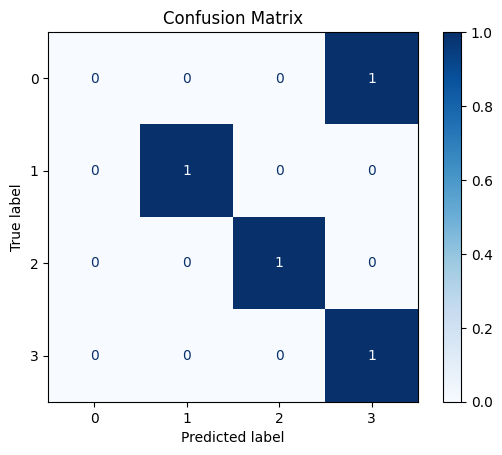


Enter New Student Details
Attendance (%): 80
Internal Marks: 45
Assignment Submitted (Yes/No): Yes
Study Hours per Day: 3
Previous CGPA: 7

Predicted Performance : Good


In [ ]:
# -------------------------------
# Upload Dataset
# -------------------------------
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

# -------------------------------
# Handle Missing Values
# -------------------------------
df.fillna(df.mode().iloc[0], inplace=True)

# -------------------------------
# Encode Categorical Data
# -------------------------------
encoders = {}

for col in df.columns:
    if df[col].dtype == "object":
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        encoders[col] = le

# -------------------------------
# Features and Target
# -------------------------------
X = df.drop("Performance", axis=1)
y = df["Performance"]

feature_columns = X.columns

# -------------------------------
# Feature Scaling
# -------------------------------
scaler = StandardScaler()
X = scaler.fit_transform(X)

# -------------------------------
# Split Dataset
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# -------------------------------
# User Input for K
# -------------------------------
k = int(input("Enter the value of K: "))

# -------------------------------
# Train KNN Model
# -------------------------------
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# -------------------------------
# Prediction on Test Data
# -------------------------------
y_pred = knn.predict(X_test)

# -------------------------------
# Performance Metrics
# -------------------------------
print("\nAccuracy :", round(accuracy_score(y_test, y_pred), 4))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

# -------------------------------
# Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

# -------------------------------
# Predict New Student
# -------------------------------
print("\nEnter New Student Details")

attendance = float(input("Attendance (%): "))
marks = float(input("Internal Marks: "))

assignment = input("Assignment Submitted (Yes/No): ")

if assignment.lower() == "yes":
    assignment = 1
else:
    assignment = 0

study_hours = float(input("Study Hours per Day: "))
cgpa = float(input("Previous CGPA: "))

new_student = pd.DataFrame(
    [[attendance, marks, assignment, study_hours, cgpa]],
    columns=feature_columns
)

new_student = scaler.transform(new_student)

prediction = knn.predict(new_student)

performance = encoders["Performance"].inverse_transform(prediction)

print("\nPredicted Performance :", performance[0])











